# Employee Attrition Prediction Project

### Introduction
This project aims to predict employee attrition by analyzing various demographic and job-related factors using a supervised machine learning approach. First, the dataset is preprocessed to encode categorical features and scale numerical ones. Then, different classification models—including Logistic Regression, Random Forest, and XGBoost—are trained on a balanced dataset using SMOTE to address class imbalance. The goal is to accurately identify employees at risk of leaving, enabling HR teams to develop proactive retention strategies and improve workforce stability. This approach combines exploratory data analysis, feature engineering, and robust modeling to deliver actionable insights into employee turnover.

### Import Libraries
Import all essential libraries needed for data processing, modeling, visualization, and evaluation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

### Load the Dataset
The IBM HR Analytics dataset was loaded into a pandas DataFrame. It contains employee-level data such as demographics, job roles, and satisfaction metrics. Viewing the first few rows helped confirm the structure and quality of the data.

In [3]:
# Load the dataset and review its structure.
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.shape

(1470, 35)

### Initial Exploration
Get an initial feel for the dataset — view column names, types, summary stats, and check for missing values.

In [4]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

#### Summary
The IBM HR Analytics dataset was successfully loaded and thoroughly inspected, confirming the presence of 1,470 records and 35 features related to employee demographics, job roles, satisfaction, and performance. All columns have complete data with no missing values, and the data types are appropriate for further analysis. This clean and well-structured dataset forms a solid basis for exploring factors influencing employee attrition and building predictive models.

### Exploratory Data Analysis (EDA)
This section explores attrition patterns across key employee attributes such as income, age, and job roles. By visualizing distributions and relationships, we gain initial insights into potential drivers of employee attrition and prepare for informed model building.

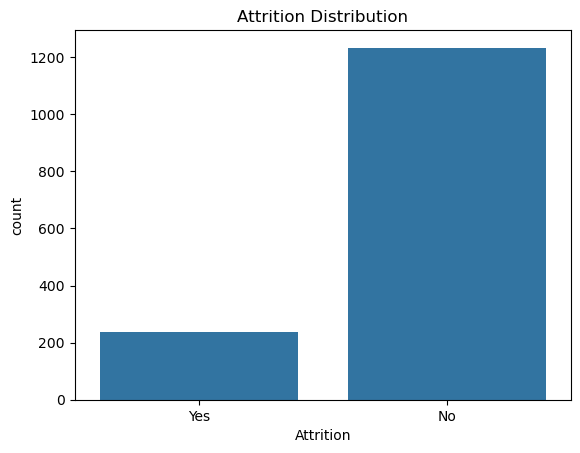

In [5]:
# Target variable(Attrition) distribution
sns.countplot(data=df, x='Attrition')
plt.title('Attrition Distribution')
plt.show()


**Inference**
The attrition distribution shows a clear class imbalance, with far more employees staying than leaving. This imbalance must be addressed during modeling to avoid biased predictions and improve the detection of actual attrition cases.

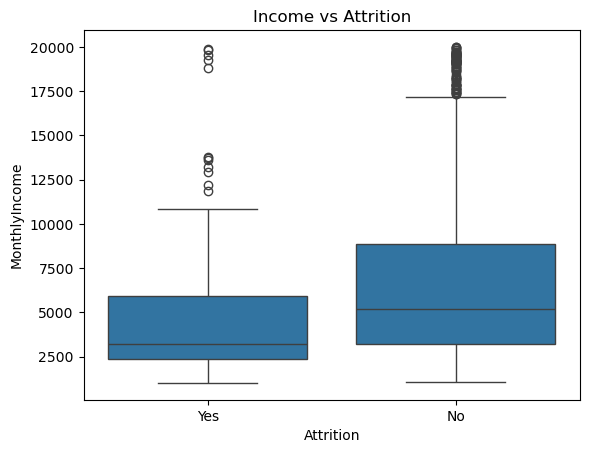

In [6]:
# Income Vs Attrition
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Income vs Attrition')
plt.show()

**Inference**
The box plot shows that employees who left the company tend to have lower monthly incomes than those who stayed, suggesting that income may be a key factor influencing attrition.

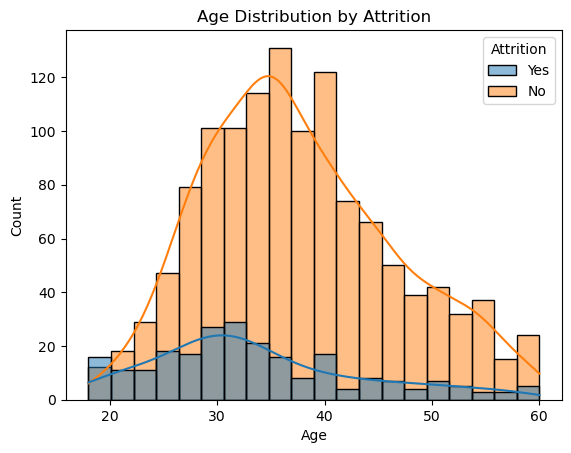

In [7]:
# Age Distribution by Attrition
sns.histplot(data=df, x='Age', hue='Attrition', bins=20, kde=True)
plt.title('Age Distribution by Attrition')
plt.show()


**Inference**
The "Age Distribution by Attrition" plot clearly shows that attrition is more prevalent among younger employees (late 20s to early 30s), while older employees exhibit a lower likelihood of leaving the company.

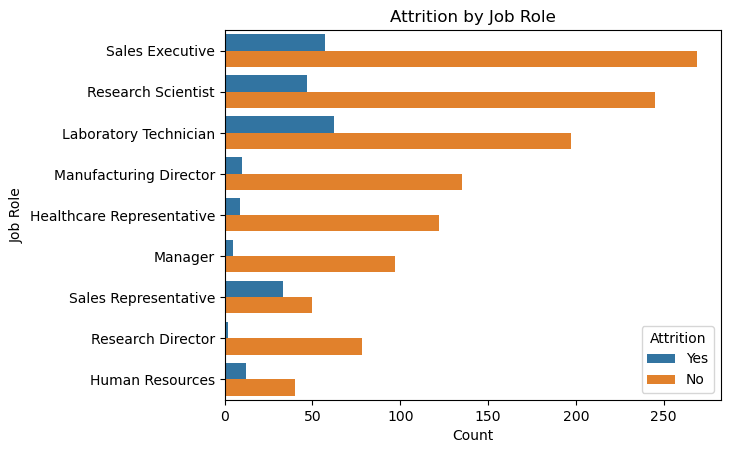

In [8]:
# Job Role vs Attrition
sns.countplot(y='JobRole', hue='Attrition', data=df)
plt.xlabel('Count')
plt.ylabel('Job Role')
plt.title('Attrition by Job Role')
plt.show()

**Inference**
The "Attrition by Job Role" plot highlights that Sales Executives, Research Scientists, and Laboratory Technicians experience the highest number of attritions, indicating these roles may require targeted retention strategies.

### Data Preprocessing
Following the exploratory data analysis and initial insights, the dataset was preprocessed to prepare it for modeling. Irrelevant columns were removed, categorical variables were encoded using label encoding, and numerical features were standardized. These steps ensure that the data is clean, consistent, and suitable for training reliable machine learning models.

In [9]:
# Removed unnecessary columns
df.drop(['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'], axis=1, inplace=True)

# Encode target
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Encode categorical features
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Feature scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop('Attrition', axis=1))
X = pd.DataFrame(scaled_features, columns=df.columns.drop('Attrition'))
y = df['Attrition']


### Train-Test Split and Handling Class Imbalance
To evaluate model performance reliably, the dataset was split into training and testing sets using stratified sampling to preserve the class distribution. Given the imbalance observed in the target variable, SMOTE (Synthetic Minority Over-sampling Technique) was applied to the training data to balance the classes and reduce bias in model learning.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

### Model Training and Evaluation
With the preprocessed and balanced dataset ready, multiple classification models were trained to predict employee attrition. Logistic Regression, Random Forest, and XGBoost were selected to provide a mix of linear and ensemble-based approaches. Each model was evaluated using classification metrics to assess their performance in identifying both attrition and non-attrition cases.

In [12]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_sm, y_train_sm)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

# XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train_sm, y_train_sm)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.94      0.77      0.85       247
           1       0.38      0.77      0.51        47

    accuracy                           0.77       294
   macro avg       0.66      0.77      0.68       294
weighted avg       0.86      0.77      0.79       294

Random Forest Results:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.60      0.26      0.36        47

    accuracy                           0.85       294
   macro avg       0.74      0.61      0.64       294
weighted avg       0.83      0.85      0.83       294

XGBoost Results:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.59      0.28      0.38        47

    accuracy                           0.85       294
   macro avg       0.73      0.62      0.65       294
weigh

**Model Performance Inference**
Logistic Regression performed relatively well in identifying attrition cases, achieving a recall of 77% for class 1, but its low precision (38%) indicates a high number of false positives. Random Forest and XGBoost models showed strong accuracy overall (85%) and performed well in predicting non-attrition cases. However, both struggled with correctly identifying attrition cases, with recall dropping below 30% for class 1. This suggests the models are favoring the majority class, and further improvement is needed to better capture true attrition cases, possibly through additional tuning or advanced sampling techniques.

#### Confusion Matrix and ROC Curve
This section visualizes model performance using the Confusion Matrix and ROC Curve. The Confusion Matrix provides a detailed breakdown of correct and incorrect predictions at a specific threshold, helping identify types of classification errors. The ROC Curve illustrates the model’s ability to distinguish between classes across all thresholds, with the AUC score summarizing overall discrimination power. Together, these tools offer comprehensive insights into each model’s strengths and weaknesses.

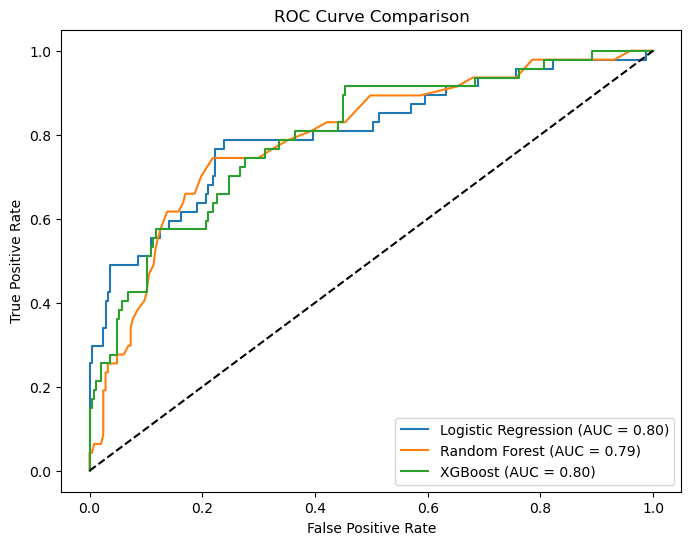

In [13]:
def plot_roc(model, X_test, y_test, label):
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc_score(y_test, y_probs):.2f})')

plt.figure(figsize=(8,6))
plot_roc(lr, X_test, y_test, 'Logistic Regression')
plot_roc(rf, X_test, y_test, 'Random Forest')
plot_roc(xgb, X_test, y_test, 'XGBoost')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

**Inference**
The ROC curve comparison indicates that Logistic Regression, Random Forest, and XGBoost models all exhibit good and very similar performance (AUCs around 0.80) in predicting attrition, suggesting no single model significantly outperforms the others in overall discriminative ability.

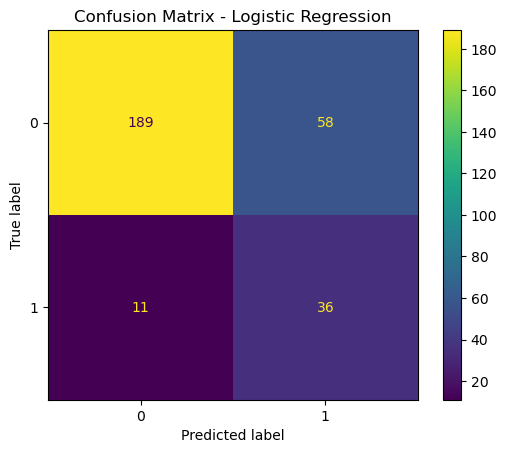

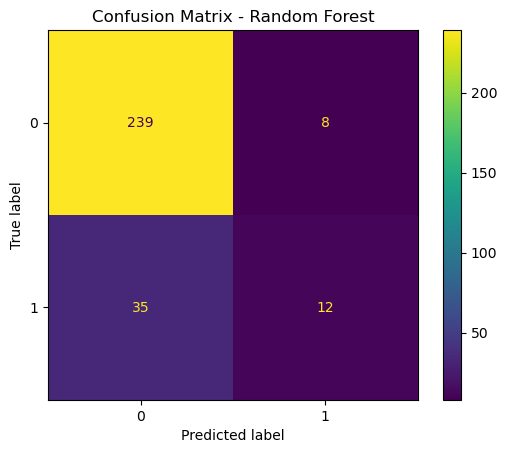

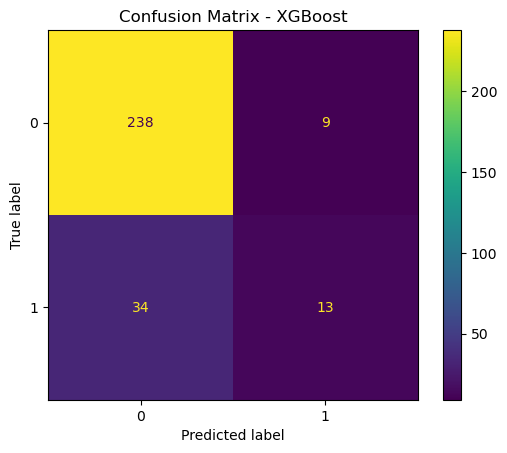

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr.classes_)
disp_lr.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Repeat for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf.classes_)
disp_rf.plot()
plt.title('Confusion Matrix - Random Forest')
plt.show()

# Repeat for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=xgb.classes_)
disp_xgb.plot()
plt.title('Confusion Matrix - XGBoost')
plt.show()


**Inference**
The confusion matrices reveal that Random Forest and XGBoost excel at correctly identifying non-attriting employees (high TN, low FP) but significantly struggle to predict actual attrition cases (low TP, high FN). Conversely, Logistic Regression is more effective at correctly identifying attriting employees (higher TP, lower FN), albeit with a higher rate of false positives compared to the other two models. This suggests Logistic Regression is better for identifying the crucial minority class.

#### Feature Importance
Understanding which features most influence model predictions is crucial for interpretability and actionable insights. This section presents the feature importance derived from Logistic Regression coefficients and the importance scores from Random Forest and XGBoost models. Comparing these helps identify key factors driving employee attrition and supports informed decision-making for retention strategies.

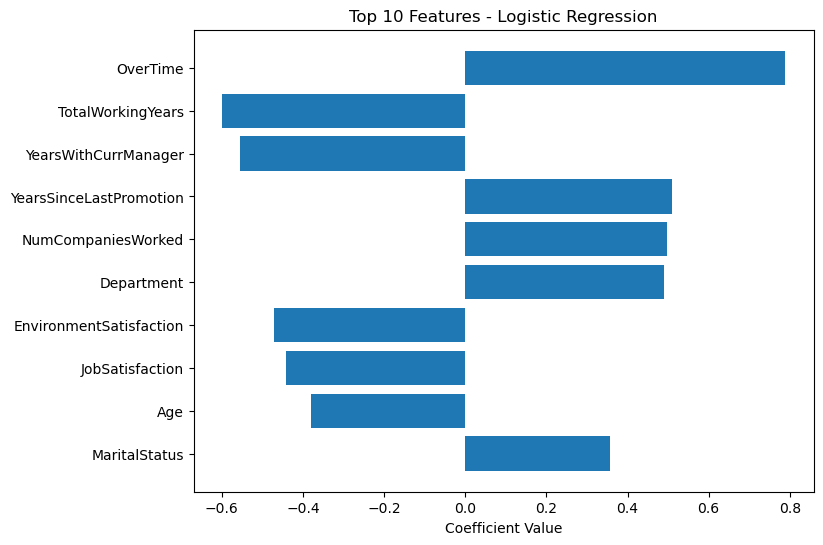

In [15]:
# Get feature names from X.columns
features = X.columns

# Extract coefficients
coefficients = lr.coef_[0]

# Create DataFrame for plotting
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

# Plot top 10
plt.figure(figsize=(8,6))
plt.barh(coef_df['Feature'].head(10), coef_df['Coefficient'].head(10))
plt.xlabel('Coefficient Value')
plt.title('Top 10 Features - Logistic Regression')
plt.gca().invert_yaxis()
plt.show()

**Inference**
This feature importance chart from Logistic Regression highlights that OverTime is the strongest positive predictor of attrition, meaning employees working overtime are most likely to leave. Conversely, TotalWorkingYears, YearsWithCurrManager, EnvironmentSatisfaction, JobSatisfaction, and Age are the strongest negative predictors, indicating that higher values in these areas significantly reduce the likelihood of attrition.

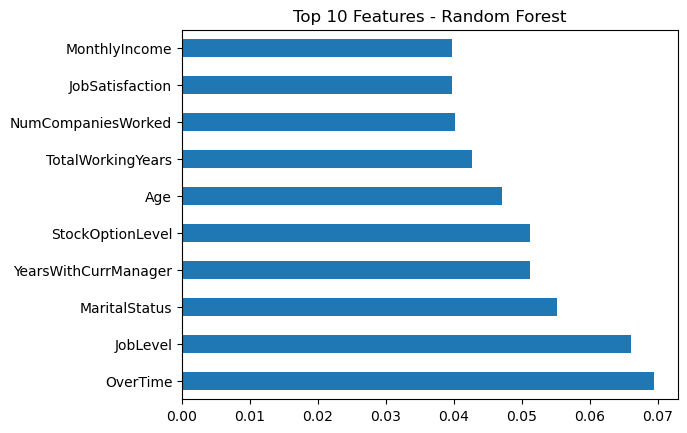

In [16]:
# Random Forest Feature Importance
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Features - Random Forest")
plt.show()

**Inference**
Random Forest feature importance chart underscores the critical role of OverTime, JobLevel, MaritalStatus, YearsWithCurrManager, and StockOptionLevel as the most influential factors in predicting employee attrition within this dataset.

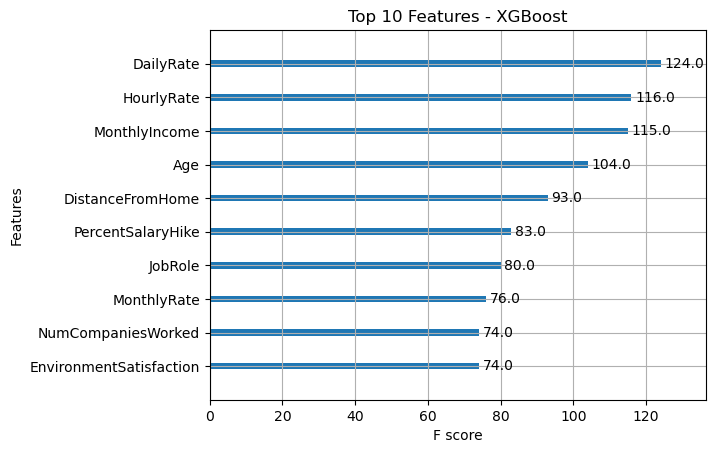

In [17]:
# XGBoost Feature Importance
from xgboost import plot_importance
plot_importance(xgb, max_num_features=10)
plt.title("Top 10 Features - XGBoost")
plt.show()

**Inference** 
The XGBoost feature importance chart indicates that DailyRate, HourlyRate, MonthlyIncome, Age, and DistanceFromHome are the most influential predictors of attrition for this model. Notably, OverTime, a top feature in other models, is not among XGBoost's top 10, suggesting differing feature prioritization across models.

### Final Project Summary
This project focused on predicting employee attrition using a comprehensive IBM HR Analytics dataset encompassing demographic, job-related, and satisfaction features. After thorough exploratory data analysis and preprocessing—including handling class imbalance with SMOTE—three machine learning models (Logistic Regression, Random Forest, and XGBoost) were trained and evaluated.

While all models demonstrated strong overall accuracy, predicting the minority class of employees likely to leave remained a challenge. Logistic Regression achieved higher recall for attrition cases, making it more suitable for early identification of at-risk employees despite a higher false positive rate. Random Forest and XGBoost showed better precision for the majority class but struggled with attrition recall.

Feature importance analysis consistently identified OverTime, Years with Current Manager, and Job Satisfaction as key predictors, emphasizing actionable areas for HR to target in retention efforts. The insights gained from this analysis can help organizations develop focused strategies such as managing overtime workload, strengthening manager-employee relationships, and improving job satisfaction to reduce turnover.

Future work may explore advanced modeling techniques, hyperparameter tuning, and feature interaction effects to further improve attrition prediction accuracy and balance between precision and recall. Overall, this project demonstrates the value of data-driven approaches in supporting workforce stability and informed human resource management.